# XGBoost Model Evaluation

Evaluación de modelos XGBoost (BALANCED vs RAW) con métricas generales y por clase.

In [1]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score,
    precision_recall_fscore_support, matthews_corrcoef, cohen_kappa_score,
    balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load Data and Models

In [2]:
BASE_PATH = Path('../../..').resolve()
DATA_PATH = BASE_PATH / 'data' / 'processed' / 'pickle'
MODELS_PATH = BASE_PATH / 'models' / 'xgboost'
RESULTS_PATH = BASE_PATH / 'data' / 'results' / 'xgboost'
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

# CARGAMOS X_train y y_train (datos reales sin alterar) PARA EL CROSS VALIDATION
# CARGAMOS X y y (el 100% de los datos) PARA EL CROSS VALIDATION
with open(DATA_PATH / 'X_train_raw.pkl', 'rb') as f:
    X_train_raw = pickle.load(f)
with open(DATA_PATH / 'y_train_raw.pkl', 'rb') as f:
    y_train_raw = pickle.load(f)

if isinstance(X_train_raw, pd.DataFrame): X_train_raw = X_train_raw.values
if isinstance(y_train_raw, pd.DataFrame): y_train_raw = y_train_raw.iloc[:, 0]

y_test = y_train_raw

# Load models (Solo para extraer sus hiperparámetros)
with open(MODELS_PATH / 'modelo_xgboost_balanced.pkl', 'rb') as f:
    model_balanced = pickle.load(f)
with open(MODELS_PATH / 'modelo_xgboost_raw.pkl', 'rb') as f:
    model_raw = pickle.load(f)

print(f"✓ Total registros para CV: {X_train_raw.shape[0]} (100% de los datos)")
print(f"✓ Distribución: {dict(pd.Series(y_train_raw).value_counts().sort_index())}")

✓ Total registros para CV: 699 (100% de los datos)
✓ Distribución: {0: np.int64(633), 1: np.int64(66)}


## 2. Generate Predictions

In [3]:
from sklearn.utils.class_weight import compute_sample_weight

print("Generando predicciones Out-of-Fold usando 5-Fold Stratified CV...\n")

# Extraemos parámetros
TRACKED_PARAMS = ['learning_rate', 'max_depth', 'min_child_weight', 'gamma', 'reg_alpha', 'reg_lambda', 'n_estimators', 'subsample', 'colsample_bytree']
params_balanced = {k: v for k, v in model_balanced.get_params().items() if k in TRACKED_PARAMS}
params_raw   = {k: v for k, v in model_raw.get_params().items()   if k in TRACKED_PARAMS}

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 1. PREDICCIONES CV MODELO RAW (CORREGIDO CON PESOS BALANCEADOS) ---
sample_weights_raw = compute_sample_weight('balanced', y_train_raw)
cv_model_raw = xgb.XGBClassifier(objective='binary:logistic', random_state=42, verbosity=0, **params_raw)

print("  Calculando predicciones CV para RAW (con pesos balanceados)...")
y_pred_raw = cross_val_predict(cv_model_raw, X_train_raw, y_train_raw, cv=outer_cv, method='predict', params={'sample_weight': sample_weights_raw}, n_jobs=-1)
y_proba_raw = cross_val_predict(cv_model_raw, X_train_raw, y_train_raw, cv=outer_cv, method='predict_proba', params={'sample_weight': sample_weights_raw}, n_jobs=-1)

# --- 2. PREDICCIONES CV MODELO ADASYN (PIPELINE) ---
cv_model_adasyn = xgb.XGBClassifier(objective='binary:logistic', random_state=42, verbosity=0, **params_balanced)
adasyn_cv = ADASYN(sampling_strategy='auto', random_state=42, n_neighbors=5)
pipeline = ImbPipeline([('adasyn', adasyn_cv), ('xgb', cv_model_adasyn)])

print("  Calculando predicciones CV para ADASYN (Pipeline)...")
y_pred_balanced = cross_val_predict(pipeline, X_train_raw, y_train_raw, cv=outer_cv, method='predict', n_jobs=-1)
y_proba_balanced = cross_val_predict(pipeline, X_train_raw, y_train_raw, cv=outer_cv, method='predict_proba', n_jobs=-1)

print("\n✓ Predicciones CV finalizadas. \nAhora el resto del notebook calculará TODAS las métricas sobre estos resultados realistas.")

Generando predicciones Out-of-Fold usando 5-Fold Stratified CV...

  Calculando predicciones CV para RAW (con pesos balanceados)...


  Calculando predicciones CV para ADASYN (Pipeline)...

✓ Predicciones CV finalizadas. 
Ahora el resto del notebook calculará TODAS las métricas sobre estos resultados realistas.


## 3. Overall Metrics

In [4]:
print("\n" + "="*70)
print("OVERALL MODEL METRICS")
print("="*70)

overall_metrics = {
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)', 
               "Cohen's Kappa"],
    'BALANCED': [
        f"{accuracy_score(y_test, y_pred_balanced):.4f}",
        f"{precision_score(y_test, y_pred_balanced, average='macro', zero_division=0):.4f}",
        f"{recall_score(y_test, y_pred_balanced, average='macro', zero_division=0):.4f}",
        f"{f1_score(y_test, y_pred_balanced, average='macro', zero_division=0):.4f}",
        f"{cohen_kappa_score(y_test, y_pred_balanced):.4f}",
    ],
    'RAW': [
        f"{accuracy_score(y_test, y_pred_raw):.4f}",
        f"{precision_score(y_test, y_pred_raw, average='macro', zero_division=0):.4f}",
        f"{recall_score(y_test, y_pred_raw, average='macro', zero_division=0):.4f}",
        f"{f1_score(y_test, y_pred_raw, average='macro', zero_division=0):.4f}",
        f"{cohen_kappa_score(y_test, y_pred_raw):.4f}",
    ]
}

df_overall = pd.DataFrame(overall_metrics)
print("\n" + df_overall.to_string(index=False))


OVERALL MODEL METRICS

           Metric BALANCED    RAW
         Accuracy   0.9156 0.8999
Precision (macro)   0.7623 0.7159
   Recall (macro)   0.6616 0.7615
 F1-Score (macro)   0.6962 0.7355
    Cohen's Kappa   0.3957 0.4718


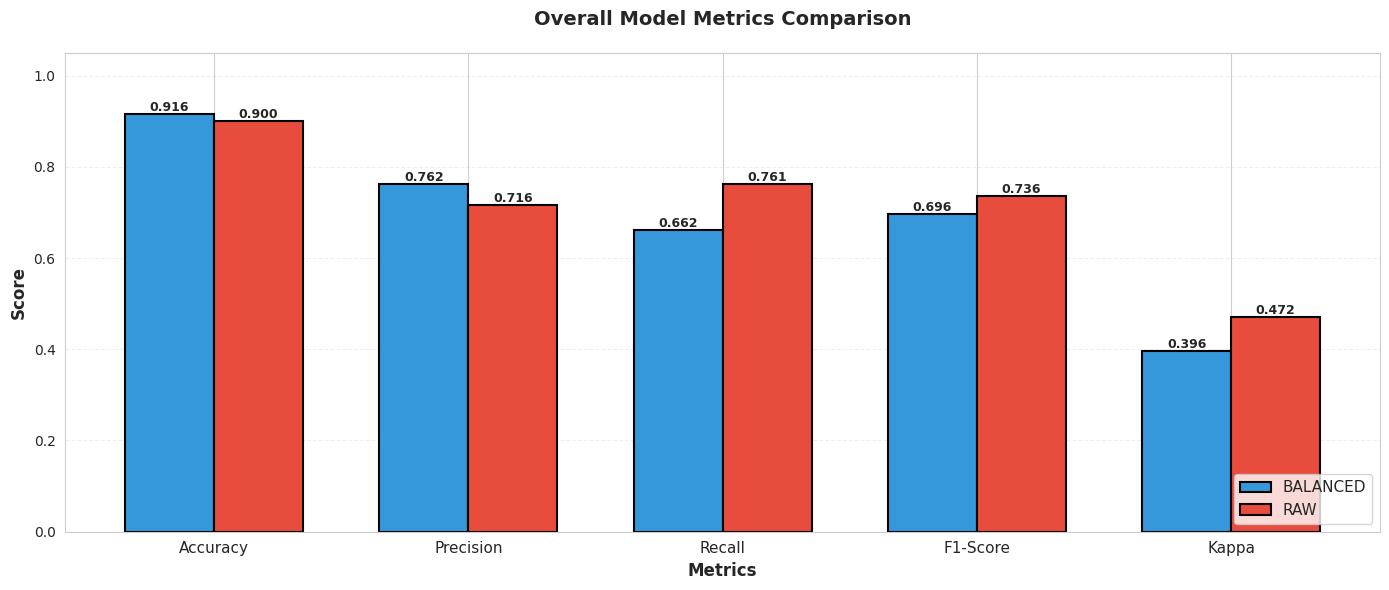

In [5]:
# Visualization of overall metrics
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', "Kappa"]
balanced_vals = [float(x) for x in df_overall['BALANCED'].values]
raw_vals = [float(x) for x in df_overall['RAW'].values]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, balanced_vals, width, label='BALANCED', color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, raw_vals, width, label='RAW', color='#e74c3c', edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Overall Model Metrics Comparison', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

## 4. Per-Class Metrics

In [6]:
print("\n" + "="*70)
print("PER-CLASS METRICS - BALANCED MODEL")
print("="*70)

prec_s, rec_s, f1_s, sup_s = precision_recall_fscore_support(y_test, y_pred_balanced, average=None)
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

sensitivity_s = []
specificity_s = []

for i in range(cm_balanced.shape[0]):
    tp = cm_balanced[i, i]
    fn = cm_balanced[i, :].sum() - tp
    fp = cm_balanced[:, i].sum() - tp
    tn = cm_balanced.sum() - (tp + fn + fp)
    
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_s.append(sens)
    specificity_s.append(spec)

df_class_balanced = pd.DataFrame({
    'Class': [0, 1],
    'Precision': prec_s,
    'Recall': rec_s,
    'F1-Score': f1_s,
    'Sensitivity': sensitivity_s,
    'Specificity': specificity_s,
    'Support': sup_s
})

print("\n" + df_class_balanced.to_string(index=False))

print("\n" + "="*70)
print("PER-CLASS METRICS - RAW MODEL")
print("="*70)

prec_r, rec_r, f1_r, sup_r = precision_recall_fscore_support(y_test, y_pred_raw, average=None)
cm_raw = confusion_matrix(y_test, y_pred_raw)

sensitivity_r = []
specificity_r = []

for i in range(cm_raw.shape[0]):
    tp = cm_raw[i, i]
    fn = cm_raw[i, :].sum() - tp
    fp = cm_raw[:, i].sum() - tp
    tn = cm_raw.sum() - (tp + fn + fp)
    
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity_r.append(sens)
    specificity_r.append(spec)

df_class_raw = pd.DataFrame({
    'Class': [0, 1],
    'Precision': prec_r,
    'Recall': rec_r,
    'F1-Score': f1_r,
    'Sensitivity': sensitivity_r,
    'Specificity': specificity_r,
    'Support': sup_r
})

print("\n" + df_class_raw.to_string(index=False))


PER-CLASS METRICS - BALANCED MODEL

 Class  Precision   Recall  F1-Score  Sensitivity  Specificity  Support
     0   0.934848 0.974724  0.954370     0.974724     0.348485      633
     1   0.589744 0.348485  0.438095     0.348485     0.974724       66

PER-CLASS METRICS - RAW MODEL

 Class  Precision   Recall  F1-Score  Sensitivity  Specificity  Support
     0    0.95624 0.932070  0.944000     0.932070     0.590909      633
     1    0.47561 0.590909  0.527027     0.590909     0.932070       66


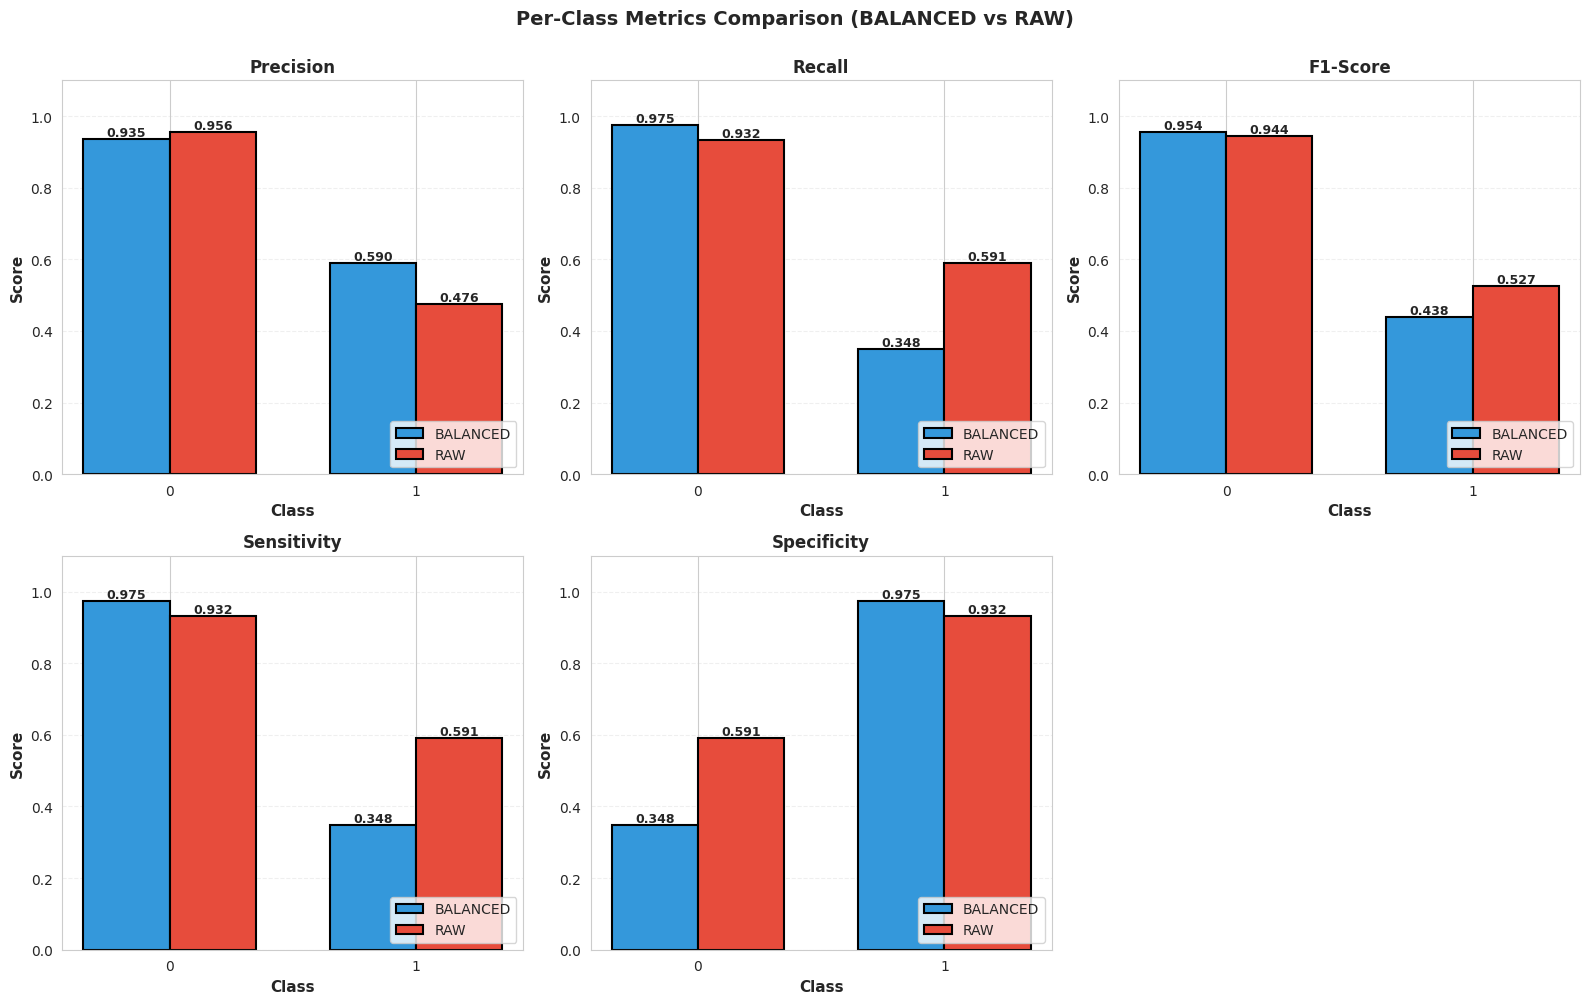

In [7]:
# Visualization of per-class metrics
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Per-Class Metrics Comparison (BALANCED vs RAW)', fontsize=14, fontweight='bold', y=1.00)

metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'Sensitivity', 'Specificity']
colors_balanced = '#3498db'
colors_raw = '#e74c3c'

for idx, metric in enumerate(metrics_to_plot):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    if metric == 'Precision':
        balanced_data = prec_s
        raw_data = prec_r
    elif metric == 'Recall':
        balanced_data = rec_s
        raw_data = rec_r
    elif metric == 'F1-Score':
        balanced_data = f1_s
        raw_data = f1_r
    elif metric == 'Sensitivity':
        balanced_data = sensitivity_s
        raw_data = sensitivity_r
    else:  # Specificity
        balanced_data = specificity_s
        raw_data = specificity_r
    
    x = np.arange(2)
    width = 0.35
    
    bars1 = ax.bar(x - width/2, balanced_data, width, label='BALANCED', color=colors_balanced, edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width/2, raw_data, width, label='RAW', color=colors_raw, edgecolor='black', linewidth=1.5)
    
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_xlabel('Class', fontsize=11, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['0', '1'])
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.1])

# Remove the 6th subplot (bottom right) since we only have 5 metrics
axes[1, 2].remove()

plt.tight_layout()
plt.show()

## 5. ROC Curves and AUC Analysis


ROC-AUC SCORES (Binary)
BALANCED AUC: 0.8428
RAW   AUC: 0.8537


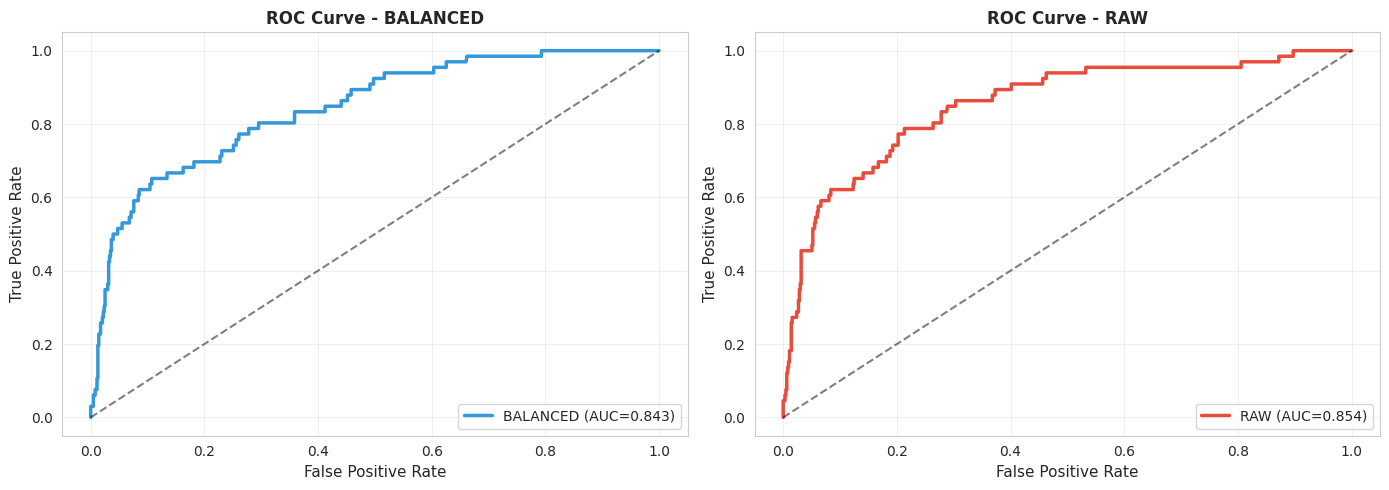

In [8]:
print("\n" + "="*70)
print("ROC-AUC SCORES (Binary)")
print("="*70)

# Para binario: usar directamente y_proba[:, 1] (prob. de clase "muere")
auc_balanced = roc_auc_score(y_test, y_proba_balanced[:, 1])
auc_raw   = roc_auc_score(y_test, y_proba_raw[:, 1])

print(f"BALANCED AUC: {auc_balanced:.4f}")
print(f"RAW   AUC: {auc_raw:.4f}")

# ROC Curves plot — una sola gráfica para binario
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_proba, auc, label, color in zip(
    axes,
    [y_proba_balanced, y_proba_raw],
    [auc_balanced, auc_raw],
    ['BALANCED', 'RAW'],
    ['#3498db', '#e74c3c']
):
    fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{label} (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC Curve - {label}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Confusion Matrices

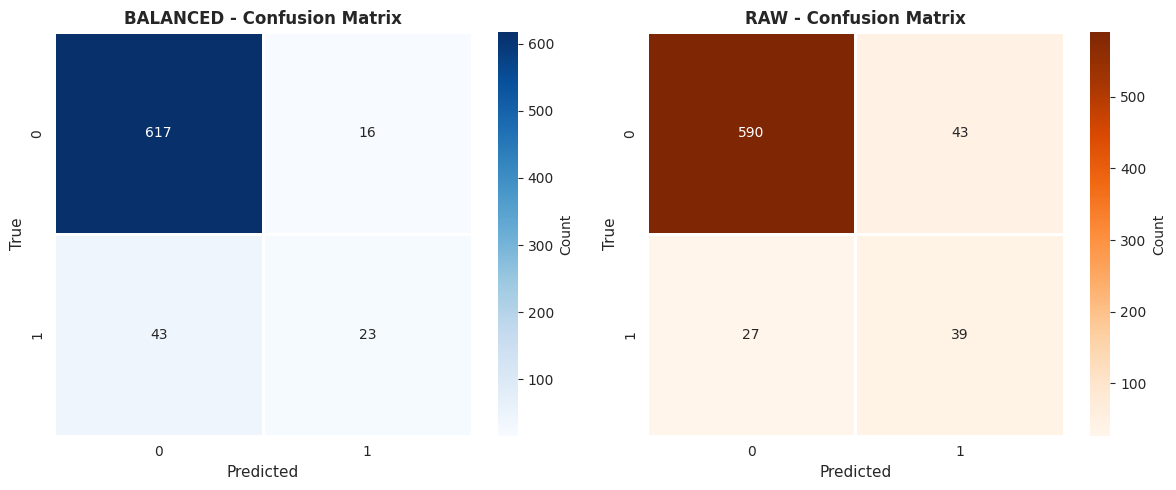

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_balanced, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'Count'}, linewidths=2)
axes[0].set_title('BALANCED - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)

sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            cbar_kws={'label': 'Count'}, linewidths=2)
axes[1].set_title('RAW - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True', fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.show()

## 7. Final Comparison and Recommendation

In [10]:
print("\n" + "="*70)
print("FINAL COMPARISON")
print("="*70)

# Key metrics for medical use
print("\nClass 0 (No Muere):")
print(f"  BALANCED - Recall: {rec_s[0]:.4f}  |  Sensitivity: {sensitivity_s[0]:.4f}  |  Specificity: {specificity_s[0]:.4f}")
print(f"  RAW   - Recall: {rec_r[0]:.4f}  |  Sensitivity: {sensitivity_r[0]:.4f}  |  Specificity: {specificity_r[0]:.4f}")

print("\nClass 1 (Muere - Critical):")
print(f"  BALANCED - Recall: {rec_s[1]:.4f}  |  Sensitivity: {sensitivity_s[1]:.4f}  |  Specificity: {specificity_s[1]:.4f}")
print(f"  RAW   - Recall: {rec_r[1]:.4f}  |  Sensitivity: {sensitivity_r[1]:.4f}  |  Specificity: {specificity_r[1]:.4f}")

print("\nMean Recall (macro):")
mean_recall_balanced = np.mean([rec_s[0], rec_s[1]])
mean_recall_raw   = np.mean([rec_r[0], rec_r[1]])
print(f"  BALANCED: {mean_recall_balanced:.4f}")
print(f"  RAW:   {mean_recall_raw:.4f}")

if mean_recall_balanced > mean_recall_raw:
    winner = "BALANCED"
else:
    winner = "RAW"

print(f"\n✅ RECOMMENDATION: {winner} model (higher average recall)")
print("\nNote: Recall is prioritized for medical mortality prediction")
print("      (detecting deaths is more critical than avoiding false alarms)")
print("="*70)



FINAL COMPARISON

Class 0 (No Muere):
  BALANCED - Recall: 0.9747  |  Sensitivity: 0.9747  |  Specificity: 0.3485
  RAW   - Recall: 0.9321  |  Sensitivity: 0.9321  |  Specificity: 0.5909

Class 1 (Muere - Critical):
  BALANCED - Recall: 0.3485  |  Sensitivity: 0.3485  |  Specificity: 0.9747
  RAW   - Recall: 0.5909  |  Sensitivity: 0.5909  |  Specificity: 0.9321

Mean Recall (macro):
  BALANCED: 0.6616
  RAW:   0.7615

✅ RECOMMENDATION: RAW model (higher average recall)

Note: Recall is prioritized for medical mortality prediction
      (detecting deaths is more critical than avoiding false alarms)


## 8. Save Results to File

In [11]:
from datetime import datetime

# Create filename with date and time
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
results_filename = RESULTS_PATH / f"evaluation_results_{timestamp}.txt"

# Get model hyperparameters
params_balanced = model_balanced.get_params()
params_raw = model_raw.get_params()

# Filter only important parameters
important_params = ['learning_rate', 'max_depth', 'min_child_weight', 'gamma', 
                   'subsample', 'colsample_bytree', 'n_estimators', 'reg_alpha', 'reg_lambda',
                   'objective', 'random_state']

params_balanced_filtered = {k: v for k, v in params_balanced.items() if k in important_params}
params_raw_filtered = {k: v for k, v in params_raw.items() if k in important_params}

# Compile all results
results_text = f"""
{'='*80}
XGBOOST MODEL EVALUATION RESULTS
Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
{'='*80}

0. MODEL HYPERPARAMETERS
{'-'*80}
BALANCED Model Parameters:
{chr(10).join(f"  {k}: {v}" for k, v in params_balanced_filtered.items())}

RAW Model Parameters:
{chr(10).join(f"  {k}: {v}" for k, v in params_raw_filtered.items())}

1. OVERALL MODEL METRICS
{'-'*80}
{df_overall.to_string(index=False)}

2. PER-CLASS METRICS - BALANCED MODEL
{'-'*80}
{df_class_balanced.to_string(index=False)}

3. PER-CLASS METRICS - RAW MODEL
{'-'*80}
{df_class_raw.to_string(index=False)}


4. ROC-AUC SCORES (Binary)
{'-'*80}
BALANCED AUC: {auc_balanced:.4f}
RAW   AUC: {auc_raw:.4f}

5. CONFUSION MATRICES
{'-'*80}
BALANCED Confusion Matrix:
{cm_balanced}

RAW Confusion Matrix:
{cm_raw}

6. FINAL COMPARISON
{'-'*80}
Class 0 (No Muere):
  BALANCED - Recall: {rec_s[0]:.4f}  |  Sensitivity: {sensitivity_s[0]:.4f}  |  Specificity: {specificity_s[0]:.4f}
  RAW   - Recall: {rec_r[0]:.4f}  |  Sensitivity: {sensitivity_r[0]:.4f}  |  Specificity: {specificity_r[0]:.4f}

Class 1 (Mortality - Critical):
  BALANCED - Recall: {rec_s[1]:.4f}  |  Sensitivity: {sensitivity_s[1]:.4f}  |  Specificity: {specificity_s[1]:.4f}
  RAW   - Recall: {rec_r[1]:.4f}  |  Sensitivity: {sensitivity_r[1]:.4f}  |  Specificity: {specificity_r[1]:.4f}

Mean Recall (macro):
  BALANCED: {mean_recall_balanced:.4f}
  RAW:   {mean_recall_raw:.4f}

7. RECOMMENDATION
{'-'*80}
✅ RECOMMENDED MODEL: {winner.upper()}
   (Higher average recall for mortality prediction)

Note: Recall is prioritized for medical mortality prediction
      (detecting deaths is more critical than avoiding false alarms)

{'='*80}
"""

# Save to file
with open(results_filename, 'w') as f:
    f.write(results_text)

print(f"✓ Results saved to: {results_filename}")
print(f"\nFile location: {results_filename.absolute()}")

✓ Results saved to: /home/pablo/Desktop/Estressss/pdg/data/results/xgboost/evaluation_results_2026-05-14_14-13-30.txt

File location: /home/pablo/Desktop/Estressss/pdg/data/results/xgboost/evaluation_results_2026-05-14_14-13-30.txt
